🛒 E-Commerce Sales Report

Notebook 1 of 3 — Sales & Financial Performance

Repository: ecommerce-analysis
Dataset: Global E-Commerce and Supply Chain Database via KaggleHub


Objective:
Analyse the financial performance of a global e-commerce operation by building a structured sales report across four dimensions:

SectionBusiness QuestionRevenue Over TimeIs the business growing month over month and year over year?Burn RateHow fast are costs consuming revenue?Cash FlowWhat is the net financial position each month?Brand PerformanceWhich brands drive the most revenue and profit — and by how much?

Output: Analysis-ready DataFrames exported for Power BI visualisation.

Stack: Python · pandas · SQLite · seaborn · matplotlib

📦 1. Dependencies & Setup

Importing all required libraries and establishing the SQLite connection used throughout the notebook.

📥 2. Data Ingestion

Downloading the dataset directly from Kaggle via kagglehub. This ensures the notebook is fully reproducible without manual file downloads.

In [5]:
import sqlite3
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
import kagglehub
import pandas as pd
# Download latest version
path = kagglehub.dataset_download("parsakh/global-e-commerce-and-supply-chain-database")

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 3.65M/3.65M [00:00<00:00, 7.92MB/s]

Extracting files...


🗄️ 3. Database Setup

Creating a local SQLite database (ecommerce_supply_chain.db) and loading the products and transactions tables.

Why SQLite?
Working through SQL rather than raw DataFrames allows us to write business logic as declarative queries — closer to how analysts work in production environments with data warehouses. It also makes the queries reusable for Power BI's DirectQuery mode.


⚠️ Note: if_exists="append" is used here. If this cell is re-run, rows will be duplicated. To avoid this, change to if_exists="replace" or add a check before loading.

In [7]:

conn = sqlite3.connect("ecommerce_supply_chain.db")
cursor = conn.cursor()

In [8]:
data_dir = "/home/codespace/.cache/kagglehub/datasets/parsakh/global-e-commerce-and-supply-chain-database/versions/1"

tables = {
    "products": "products.csv",
    "transactions": "transactions.csv",
}

for table_name, filename in tables.items():
    df = pd.read_csv(os.path.join(data_dir, filename))
    df.to_sql(table_name, conn, if_exists="append", index=False)
    print(f"Loaded {table_name}: {df.shape[0]} rows")

Loaded products: 500 rows


Loaded transactions: 100000 rows


🔍 4. Data Exploration

Running a quick statistical summary of the transactions table to understand value ranges, identify potential outliers, and confirm data types before building any metrics.

In [9]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM transactions t
"""
transactions_df = pd.read_sql_query(sql_query, conn)

conn.close()

In [10]:
transactions_df.describe()

,quantity,unit_price_usd,discount_pct,revenue_usd,cost_usd,profit_usd,shipping_cost_usd
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2.32044,240.483215,0.055375,528.719600,349.721733,178.997867,20.426383
std,1.92016,255.433985,0.063333,856.638673,660.953549,232.127596,29.946099
min,1.00000,8.060000,0.000000,6.450000,4.580000,-0.030000,0.000000
25%,1.00000,70.830000,0.000000,109.130000,57.460000,45.410000,0.900000
50%,2.00000,164.510000,0.050000,241.580000,133.820000,102.760000,11.040000
75%,3.00000,280.520000,0.100000,593.460000,348.360000,211.145000,24.600000
max,10.00000,1191.590000,0.250000,11915.900000,8936.900000,2979.000000,371.250000


In [11]:
transactions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   transaction_id     100000 non-null  str    
 1   customer_id        100000 non-null  str    
 2   product_id         100000 non-null  str    
 3   date               100000 non-null  str    
 4   quantity           100000 non-null  int64  
 5   unit_price_usd     100000 non-null  float64
 6   discount_pct       100000 non-null  float64
 7   revenue_usd        100000 non-null  float64
 8   cost_usd           100000 non-null  float64
 9   profit_usd         100000 non-null  float64
 10  shipping_cost_usd  100000 non-null  float64
 11  channel            100000 non-null  str    
 12  payment_method     100000 non-null  str    
 13  status             100000 non-null  str    
 14  country            100000 non-null  str    
 15  category           100000 non-null  str    
dtypes: float64(6),

In [12]:
conn = sqlite3.connect('ecommerce_supply_chain.db')

sql_query = """SELECT *
FROM products p
"""
products_df = pd.read_sql_query(sql_query, conn)

In [13]:
products_df.head()

,product_id,name,category,brand,unit_price_usd,unit_cost_usd,weight_kg,is_active,launch_date
0,PROD0001,CoreBrand Books Item 1,Books,BoldEdge,25.82,16.78,2.13,1,2019-11-23
1,PROD0002,PrimeLine Clothing Item 2,Clothing,ClearView,108.37,48.77,2.86,1,2021-08-14
2,PROD0003,GlowUp Home Item 3,Home & Kitchen,StyleCo,214.46,128.68,6.86,1,2019-04-09
3,PROD0004,HomePro Electronics Item 4,Electronics,PureForm,830.21,622.66,3.25,1,2019-08-28
4,PROD0005,HomePro Clothing Item 5,Clothing,ClearView,19.56,8.80,8.86,1,2020-11-18


In [14]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      500 non-null    str    
 1   name            500 non-null    str    
 2   category        500 non-null    str    
 3   brand           500 non-null    str    
 4   unit_price_usd  500 non-null    float64
 5   unit_cost_usd   500 non-null    float64
 6   weight_kg       500 non-null    float64
 7   is_active       500 non-null    int64  
 8   launch_date     500 non-null    str    
dtypes: float64(3), int64(1), str(5)
memory usage: 35.3 KB


📈 5. Revenue Over Time

Aggregating total revenue by year and month to build a time-series view of business performance.

This is the foundation of the sales report — everything else (burn rate, cash flow, growth) is derived from this monthly revenue base.

In [18]:
sql_query = """SELECT strftime('%Y', t.date) AS year_val,
strftime('%m', t.date) AS month_val
  ,SUM(t.revenue_usd) AS total_revenue
FROM transactions t
GROUP BY year_val,month_val
"""
revenue_df = pd.read_sql_query(sql_query, conn)

🔥 6. Burn Rate Analysis

Calculating two burn rate variants to measure how efficiently the business converts costs into revenue:

MetricFormulaInterpretationGross Burn Ratecost_usd + shipping_cost_usdTotal cash spent per month regardless of revenueNet Burn Rate(cost_usd + shipping_cost_usd) − revenue_usdNet cash consumed after revenue; negative = profitable month

A consistently negative Net Burn Rate means the business is generating more than it spends — the ideal state. Positive values signal months where costs outpaced income.

In [19]:
sql_query = """SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,
   ((SUM(cost_usd) +SUM(shipping_cost_usd)) - SUM(revenue_usd)) AS Net_Burn_Rate,
    SUM(cost_usd) +SUM(shipping_cost_usd) AS Gross_Burn_Rate
FROM transactions t
GROUP BY year_val, month_val
ORDER BY year_val DESC, month_val DESC;
"""
Net_Burn_Rate_df = pd.read_sql_query(sql_query, conn)

📊 Revenue vs Net Burn Rate — Visual Comparison

Plotting both metrics side by side to identify whether periods of high revenue correspond to lower burn — or whether costs scale proportionally with sales volume.

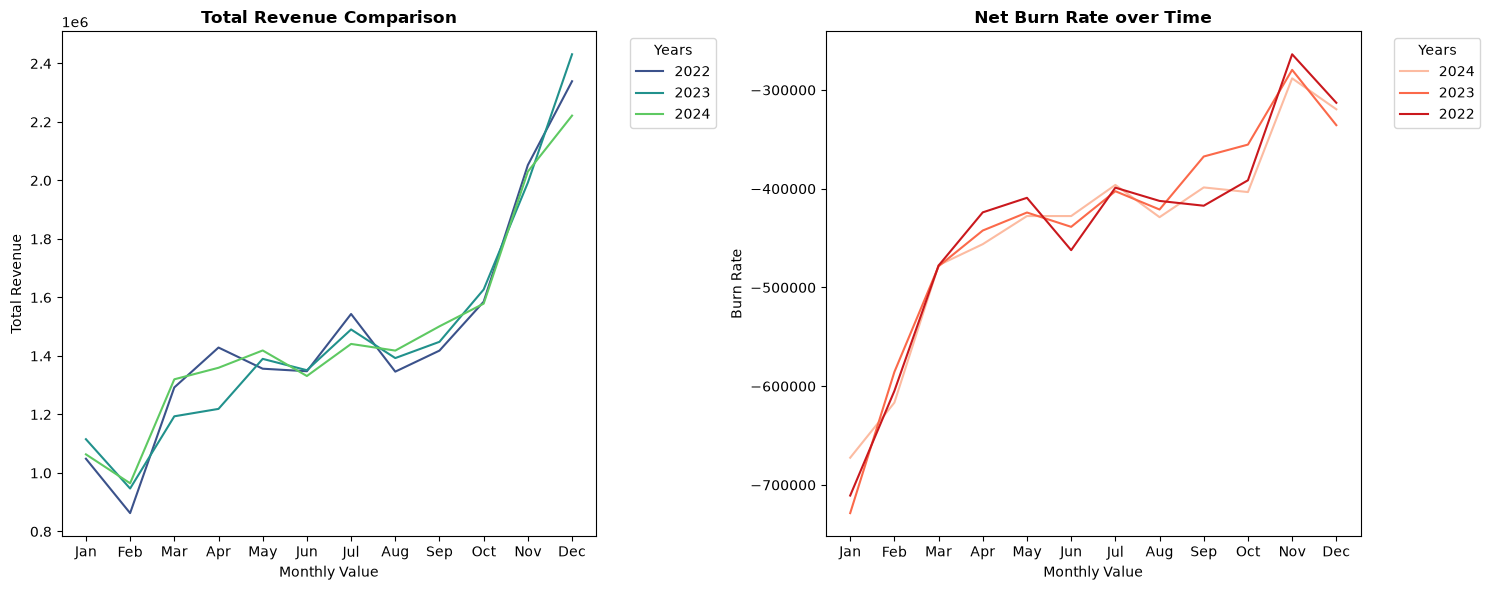

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
months_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]


sns.lineplot(x='month_val', y='total_revenue', data=revenue_df, hue='year_val', palette='viridis', legend='full', ax=ax1)

ax1.set_title("Total Revenue Comparison", fontsize=12, fontweight='bold')
ax1.set_xlabel("Monthly Value")
ax1.set_ylabel("Total Revenue")

ax1.set_xticks(ticks=range(len(revenue_df["month_val"].unique())))
ax1.set_xticklabels(months_labels[:len(revenue_df["month_val"].unique())])

ax1.legend(title="Years", bbox_to_anchor=(1.05, 1), loc="upper left")



sns.lineplot(x='month_val', y='Net_Burn_Rate', data=Net_Burn_Rate_df, hue='year_val', palette='Reds', legend='full', ax=ax2)

ax2.set_title("Net Burn Rate over Time", fontsize=12, fontweight='bold')
ax2.set_xlabel("Monthly Value")
ax2.set_ylabel("Burn Rate")

ax2.set_xticks(ticks=range(len(Net_Burn_Rate_df["month_val"].unique())))
ax2.set_xticklabels(months_labels[:len(Net_Burn_Rate_df["month_val"].unique())])

ax2.legend(title="Years", bbox_to_anchor=(1.05, 1), loc="upper left")




plt.tight_layout()
plt.show()


💰 7. Monthly Cash Flow

Cash flow is the clearest single indicator of business health — it represents what actually remains after all costs are paid.

Formula: Cash Flow = revenue_usd − (cost_usd + shipping_cost_usd)

Unlike burn rate (which focuses on the cost side), cash flow is framed from the revenue side — making it more intuitive for reporting to non-technical stakeholders and leadership dashboards.

In [22]:
sql_query = """SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,

    SUM(revenue_usd)-(SUM(cost_usd) + SUM(shipping_cost_usd)) as Cashflow
FROM transactions t
GROUP BY year_val, month_val
ORDER BY year_val DESC, month_val ASC;
"""
Cashflow_df = pd.read_sql_query(sql_query, conn)

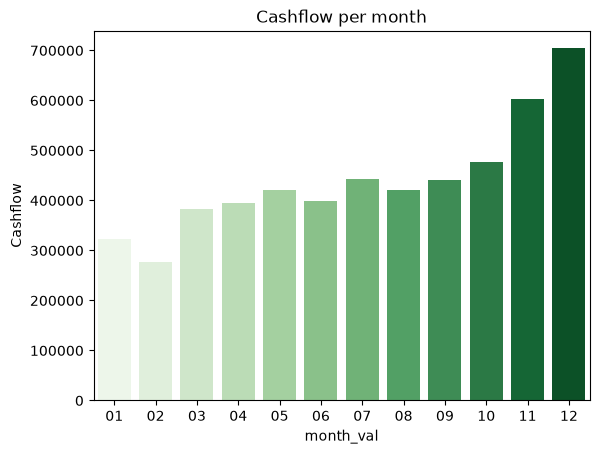

In [ ]:
sns.barplot(data=Cashflow_df,x="month_val", y="Cashflow",errorbar=None,hue="month_val",palette="Greens")
plt.title("Cashflow per month")


📅 8. Year-over-Year (YoY) Revenue Growth

Using a CTE + LAG window function to compare each year's revenue against the previous year.

YoY growth is the primary metric used by investors and leadership to assess business trajectory. A LAG function is used here rather than a self-join to keep the query clean and readable.

In [24]:
sql_query = """WITH Yearly_Revenue_CTE AS (
    SELECT 
        strftime('%Y', t.date) AS year_val,
        SUM(t.revenue_usd) AS Total_Revenue
    FROM transactions t
    GROUP BY year_val
)
SELECT 
    year_val,
    Total_Revenue,
    LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC) AS Previous_Year_Revenue,
    ROUND(
        ((Total_Revenue - LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC)) 
        / LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC)) * 100, 
        2
    ) AS YoY_Growth_Percent
FROM Yearly_Revenue_CTE
ORDER BY year_val ASC;
"""
YoY_df = pd.read_sql_query(sql_query, conn)

In [16]:
YoY_df.head()

,year_val,Total_Revenue,Previous_Year_Revenue,YoY_Growth_Percent
0,2022,1.057358e+08,NaN,NaN
1,2023,1.055949e+08,1.057358e+08,-0.13
2,2024,1.059010e+08,1.055949e+08,0.29


📆 9. Month-over-Month (MoM) Revenue Growth

Drilling down from annual to monthly growth to identify seasonal patterns, growth spikes, and declining periods that YoY figures can mask.

Months are colour-coded green (growth) and red (decline) for immediate visual clarity.

In [25]:
sql_query = """
WITH Monthly_Revenue_CTE AS (
    SELECT 
        strftime('%Y', t.date) AS year_val,
        strftime('%m', t.date) AS month_val,
        SUM(t.revenue_usd) AS Total_Revenue
    FROM transactions t
    GROUP BY year_val, month_val
)
SELECT 
    year_val,
    month_val,
    Total_Revenue,
    LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC) AS Previous_Month_Revenue,
    ROUND(
        ((Total_Revenue - LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC)) 
        / LAG(Total_Revenue, 1) OVER (ORDER BY year_val ASC, month_val ASC)) * 100, 
        2
    ) AS MoM_Growth_Percent
FROM Monthly_Revenue_CTE
ORDER BY year_val ASC, month_val ASC;
"""
MoM_df = pd.read_sql_query(sql_query, conn)


/tmp/ipykernel_5750/2214301772.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_5750/2214301772.py:7: UserWarning: The palette list has more values (36) than needed (12), which may not be intended.
  ax = sns.barplot(


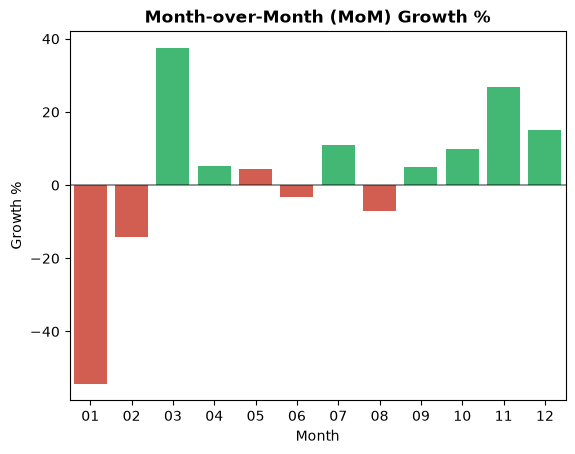

In [ ]:
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in MoM_df['MoM_Growth_Percent']]

# 2. Set up the figure size
plt.figsize=(10, 5)

# 3. Pass the custom colors list into the palette argument
ax = sns.barplot(
    data=MoM_df, 
    x="month_val", 
    y="MoM_Growth_Percent", 
    palette=colors,errorbar=None
)

# 4. Add a horizontal line at 0 to make the separation visually perfect
ax.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.5)

# 5. Clean up labels and title
ax.set_title("Month-over-Month (MoM) Growth %", fontsize=12, fontweight='bold')
ax.set_xlabel("Month")
ax.set_ylabel("Growth %")

plt.show()

🏷️ 10. Brand Performance Analysis

Joining transactions with products to break down revenue and profitability by brand.

Filters applied:


Only status = 'completed' transactions are included — cancelled or pending orders are excluded to reflect actual recognised revenue.


Metrics per brand:


gross_revenue — total income generated
total_cogs — combined product cost and shipping
gross_profit — what remains after direct costs

In [28]:
sql_query = """
SELECT 
    strftime('%Y', t.date) AS year_val,
    strftime('%m', t.date) AS month_val,
    p.brand as brand,
    SUM(t.revenue_usd) AS gross_revenue,
    (SUM(t.cost_usd) + SUM(t.shipping_cost_usd)) AS total_cogs,
    (SUM(t.revenue_usd) - (SUM(t.cost_usd) + SUM(t.shipping_cost_usd))) AS gross_profit
FROM transactions t
JOIN products p ON t.product_id = p.product_id
WHERE t.status = 'completed'
GROUP BY year_val, month_val, p.brand
ORDER BY year_val DESC, month_val DESC, gross_profit DESC;
"""
Profitable_Brands_df = pd.read_sql_query(sql_query, conn)

/tmp/ipykernel_5750/110555153.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_totals, x='brand', y='gross_profit', palette='viridis', ax=ax1)
/tmp/ipykernel_5750/110555153.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_totals, x='brand', y='gross_revenue', palette='magma', ax=ax2)


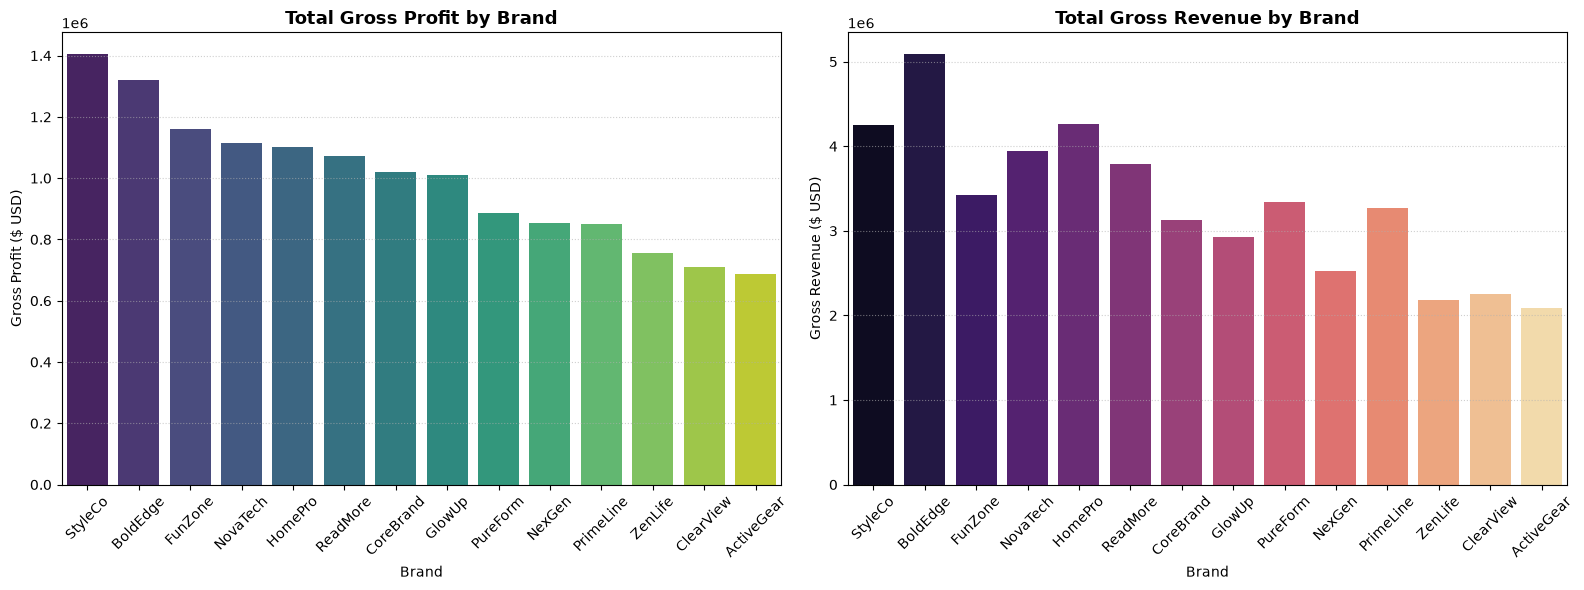

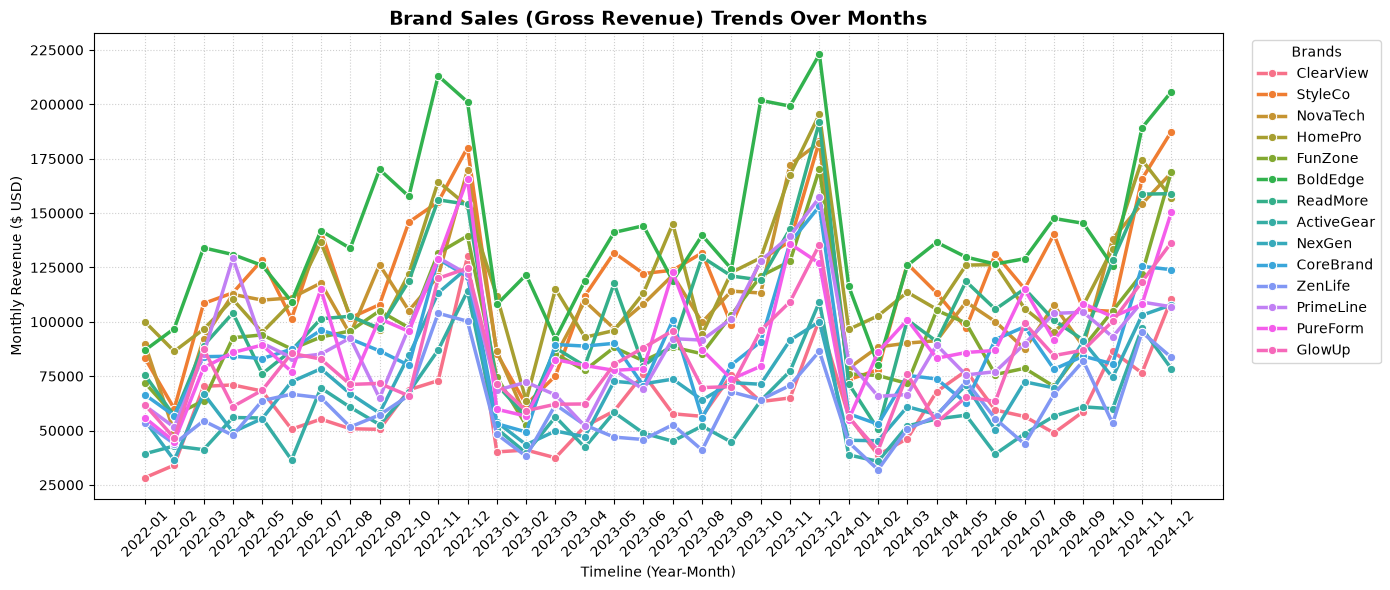

In [ ]:
brand_totals = Profitable_Brands_df.groupby('brand')[['gross_revenue', 'gross_profit']].sum().reset_index()
brand_totals = brand_totals.sort_values(by='gross_profit', ascending=False)

timeline_df = Profitable_Brands_df.copy()
timeline_df['year_month'] = timeline_df['year_val'] + '-' + timeline_df['month_val']
timeline_df = timeline_df.sort_values(by='year_month')

# =====================================================================
# VISUALIZATION 1 & 2: Profit & Revenue Comparison (Side-by-Side)
# =====================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=brand_totals, x='brand', y='gross_profit', palette='viridis', ax=ax1)
ax1.set_title("Total Gross Profit by Brand", fontsize=13, fontweight='bold')
ax1.set_xlabel("Brand")
ax1.set_ylabel("Gross Profit ($ USD)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

sns.barplot(data=brand_totals, x='brand', y='gross_revenue', palette='magma', ax=ax2)
ax2.set_title("Total Gross Revenue by Brand", fontsize=13, fontweight='bold')
ax2.set_xlabel("Brand")
ax2.set_ylabel("Gross Revenue ($ USD)")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# =====================================================================
# VISUALIZATION 3: Sales Trends Over Time by Brand
# =====================================================================
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=timeline_df, 
    x='year_month', 
    y='gross_revenue', 
    hue='brand', 
    marker='o', 
    linewidth=2.5
)

plt.title("Brand Sales (Gross Revenue) Trends Over Months", fontsize=14, fontweight='bold')
plt.xlabel("Timeline (Year-Month)")
plt.ylabel("Monthly Revenue ($ USD)")
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(title="Brands", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

🥇 11. Top 3 Brands & Revenue Concentration

Using a CTE + SUM window function to calculate each brand's share of total revenue, then limiting to the top 3.

Revenue concentration is an important business risk metric — if 3 brands represent 70%+ of revenue, the business is heavily dependent on a small number of performers. This query surfaces that concentration directly.

In [21]:
sql_query = """
WITH Brand_Sales AS (
    -- Step 1: Calculate total revenue for each individual brand
    SELECT 
        p.brand AS brand,
        SUM(t.revenue_usd) AS brand_revenue
    FROM transactions t
    JOIN products p ON t.product_id = p.product_id
    WHERE t.status = 'completed'
    GROUP BY p.brand
)
SELECT 
    brand,
    brand_revenue,
    -- Step 2: Divide brand revenue by the global total (calculated via window function)
    ROUND(
        (brand_revenue / SUM(brand_revenue) OVER ()) * 100, 
        2
    ) AS percentage_of_total
FROM Brand_Sales
ORDER BY brand_revenue DESC
LIMIT 3
"""

Top_3_Brands_df = pd.read_sql_query(sql_query, conn)



In [22]:
print(Top_3_Brands_df)

      brand  brand_revenue  percentage_of_total
0  BoldEdge   1.833225e+08                10.95
1   HomePro   1.535442e+08                 9.17
2   StyleCo   1.532463e+08                 9.15


✅ 12. Summary & Key Findings

This notebook delivered a structured financial overview of the e-commerce operation across four analytical dimensions. Below are the conclusions drawn from each section:


Revenue Over Time


Revenue was aggregated monthly and compared across years, enabling identification of seasonal peaks and growth cycles.
The multi-year line chart reveals whether revenue is on an upward trajectory or showing signs of plateau — a critical signal for business planning.


Burn Rate


Gross burn rate captures total operational expenditure (product cost + shipping) each month.
Net burn rate — the difference between costs and revenue — identifies months where the business operated at a loss vs. months with positive margin.
Monitoring net burn rate alongside revenue prevents the misleading interpretation of high-revenue months that are simultaneously high-cost.


Cash Flow


Monthly cash flow confirms that revenue growth is translating into actual retained value.
Negative cash flow months, even during high-revenue periods, indicate cost structures that need review — particularly shipping cost efficiency.


Month-over-Month Growth


MoM growth percentages highlight volatility in the revenue stream.
Green/red colour coding immediately communicates momentum to stakeholders without requiring numerical interpretation.


Brand Performance


Not all brands contribute equally — some generate high revenue with low margin, while others show the inverse.
The side-by-side gross profit vs. gross revenue comparison is essential: a brand that ranks highly on revenue but poorly on profit may be doing more harm than good at scale.


Top 3 Brands


The top 3 brands and their combined % of total revenue quantify revenue concentration risk.
A high concentration (>60%) signals over-reliance on a small brand portfolio — a strategic vulnerability worth flagging in executive reporting.


